# Hotel Booking Cancellation Analysis

## Main Question

Which booking characteristics are associated with cancellations, and can a simple model predict whether a booking will be canceled?

In [1]:
#Import libraries
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd 

In [2]:
# Check the working directory
print(Path.cwd())

C:\Users\danie\hotel-booking-analysis\notebooks


In [3]:
# Load the CSV
data_path = Path("../data/raw/bookings.csv")
df = pd.read_csv(data_path)
print("Rows and columns:", df.shape)
display(df.head())

Rows and columns: (2000, 20)


,booking_id,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,country,market_segment,deposit_type,customer_type,adr,is_repeated_guest,previous_cancellations,booking_changes,total_of_special_requests
0,SYN-00001,City Hotel,1,42,2025,January,1,1,1,0.0,0,NaN,Direct,No Deposit,Transient,105.87,0,0,0,0
1,SYN-00002,City Hotel,0,55,2025,December,0,5,3,0.0,0,NaN,Online TA,No Deposit,Transient-Party,178.38,0,1,0,1
2,SYN-00003,City Hotel,0,40,2024,June,0,3,1,0.0,0,Canada,Online TA,No Deposit,Transient,197.95,0,0,0,1
3,SYN-00004,Resort Hotel,1,123,2024,November,0,2,2,0.0,0,Germany,Corporate,Non Refund,Transient-Party,209.03,0,0,0,2
4,SYN-00005,Resort Hotel,0,146,2025,December,0,3,2,0.0,1,United Kingdom,Offline TA/TO,Non Refund,Transient,158.57,0,0,0,0


In [4]:
# Diagnose a missing-file error
print(Path.cwd())
print(data_path.resolve())
print(data_path.exists())

C:\Users\danie\hotel-booking-analysis\notebooks
C:\Users\danie\hotel-booking-analysis\data\raw\bookings.csv
True


In [5]:
# List the columns
print(df.columns.tolist())

['booking_id', 'hotel', 'is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'country', 'market_segment', 'deposit_type', 'customer_type', 'adr', 'is_repeated_guest', 'previous_cancellations', 'booking_changes', 'total_of_special_requests']


In [6]:
# Inspect types and completeness
df.info();

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 20 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   booking_id                 2000 non-null   str    
 1   hotel                      2000 non-null   str    
 2   is_canceled                2000 non-null   int64  
 3   lead_time                  2000 non-null   int64  
 4   arrival_date_year          2000 non-null   int64  
 5   arrival_date_month         2000 non-null   str    
 6   stays_in_weekend_nights    2000 non-null   int64  
 7   stays_in_week_nights       2000 non-null   int64  
 8   adults                     2000 non-null   int64  
 9   children                   1969 non-null   float64
 10  babies                     2000 non-null   int64  
 11  country                    1708 non-null   str    
 12  market_segment             2000 non-null   str    
 13  deposit_type               2000 non-null   str    
 14  cus

In [7]:
# Summary statistics
display(df.describe())
display(df.describe(include="all").T)

,is_canceled,lead_time,arrival_date_year,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,adr,is_repeated_guest,previous_cancellations,booking_changes,total_of_special_requests
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,1969.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,0.288500,78.377000,2024.521000,1.080500,3.023500,1.993500,0.342306,0.027000,155.307925,0.099500,0.063500,0.372000,0.830000
std,0.453178,55.238433,0.499684,0.934054,1.737371,0.617777,0.661548,0.162124,43.254188,0.299407,0.299186,0.683264,0.967765
min,0.000000,1.000000,2024.000000,0.000000,1.000000,1.000000,0.000000,0.000000,45.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,37.000000,2024.000000,0.000000,2.000000,2.000000,0.000000,0.000000,125.827500,0.000000,0.000000,0.000000,0.000000
50%,0.000000,66.000000,2025.000000,1.000000,3.000000,2.000000,0.000000,0.000000,153.295000,0.000000,0.000000,0.000000,1.000000
75%,1.000000,107.000000,2025.000000,2.000000,4.000000,2.000000,0.000000,0.000000,183.320000,0.000000,0.000000,1.000000,1.000000
max,1.000000,375.000000,2025.000000,3.000000,7.000000,4.000000,2.000000,1.000000,288.130000,1.000000,3.000000,3.000000,4.000000


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
booking_id,2000,2000,SYN-00001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
hotel,2000,2,City Hotel,1171,NaN,NaN,NaN,NaN,NaN,NaN,NaN
is_canceled,2000.0,NaN,NaN,NaN,0.2885,0.453178,0.0,0.0,0.0,1.0,1.0
lead_time,2000.0,NaN,NaN,NaN,78.377,55.238433,1.0,37.0,66.0,107.0,375.0
arrival_date_year,2000.0,NaN,NaN,NaN,2024.521,0.499684,2024.0,2024.0,2025.0,2025.0,2025.0
arrival_date_month,2000,12,September,190,NaN,NaN,NaN,NaN,NaN,NaN,NaN
stays_in_weekend_nights,2000.0,NaN,NaN,NaN,1.0805,0.934054,0.0,0.0,1.0,2.0,3.0
stays_in_week_nights,2000.0,NaN,NaN,NaN,3.0235,1.737371,1.0,2.0,3.0,4.0,7.0
adults,2000.0,NaN,NaN,NaN,1.9935,0.617777,1.0,2.0,2.0,2.0,4.0
children,1969.0,NaN,NaN,NaN,0.342306,0.661548,0.0,0.0,0.0,0.0,2.0


In [8]:
# Count missing values
missing_values = df.isna().sum().sort_values(ascending=False)
display(missing_values.head(15))

country                    292
children                    31
booking_id                   0
hotel                        0
lead_time                    0
is_canceled                  0
arrival_date_year            0
arrival_date_month           0
stays_in_week_nights         0
stays_in_weekend_nights      0
adults                       0
babies                       0
market_segment               0
deposit_type                 0
customer_type                0
dtype: int64

In [9]:
# Count duplicate rows
duplicate_count = df.duplicated().sum()
print("Duplicate rows: ", duplicate_count)

Duplicate rows:  0


In [10]:
# Create a clean copy
clean = df.drop_duplicates().copy()

In [11]:
# Fill selected missing values
clean["children"] = clean["children"].fillna(0)

In [12]:
# Create total-guests and total-nights fields
clean["total_guests"] = (
    clean["adults"]
    + clean["children"]
    + clean["babies"]
)

clean["total_nights"] = (
    clean["stays_in_weekend_nights"]
    + clean["stays_in_week_nights"]
)

In [13]:
# Remove clearly invalid rows
clean = clean[clean["total_guests"] > 0]
clean = clean[clean["total_nights"] > 0]
clean = clean[clean["adr"] >= 0]

In [14]:
# Compare before and after
print("Original rows:", len(df))
print("Cleaned rows:", len(clean))
print("Rows removed:", len(df) - len(clean))

Original rows: 2000
Cleaned rows: 2000
Rows removed: 0


In [15]:
# Save the cleaned dataset
processed_path = Path("../data/processed/clean_bookings.csv")
clean.to_csv(processed_path, index=False)
print(processed_path.exists())

True


### Answer Business Questison 

In [16]:
# Question 1: What percentage of bookings were canceled?
cancellation_rate = clean["is_canceled"].mean()
print(f"Cancellation rate: {cancellation_rate:.1%}")

Cancellation rate: 28.8%


In [17]:
# Question 2: Does cancellation rate change with lead time?
clean["lead_time_group"] = pd.cut(
 clean["lead_time"],
 bins=[-1, 7, 30, 90, 180, float("inf")],
 labels=[
 "0-7 days",
 "8-30 days",
 "31-90 days",
 "91-180 days",
 "181+ days",
 ],
)
lead_time_results = (
 clean.groupby("lead_time_group", observed=False)["is_canceled"]
 .agg(["mean", "count"])
)
display(lead_time_results)

,mean,count
lead_time_group,,
0-7 days,0.148148,27
8-30 days,0.255556,360
31-90 days,0.275316,948
91-180 days,0.320652,552
181+ days,0.380531,113


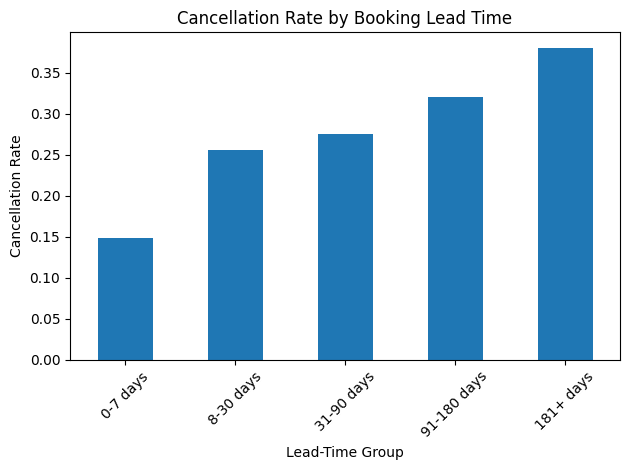

In [19]:
lead_time_results["mean"].plot(kind="bar")
plt.title("Cancellation Rate by Booking Lead Time")
plt.xlabel("Lead-Time Group")
plt.ylabel("Cancellation Rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(
 "../reports/figures/cancellations_by_lead_time.png",
 dpi=150,
)
plt.show()

In [20]:
# Question 3: Does deposit type relate to cancellation?
deposit_results = (
 clean.groupby("deposit_type")["is_canceled"]
 .agg(["mean", "count"])
     .sort_values("mean", ascending=False)
)
display(deposit_results)

,mean,count
deposit_type,,
Non Refund,0.428000,250
No Deposit,0.270595,1663
Refundable,0.229885,87
